In [136]:
import tensorflow as tf
import os

In [137]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [138]:
gpus

[]

In [139]:
tf.config.experimental.list_physical_devices('GPU')

[]

# Removing Dodgy images

In [140]:
import cv2
import imghdr

In [141]:
data_dir = 'data'

In [142]:
os.listdir(os.path.join(data_dir, 'ant'))

['Ant_1.jpg',
 'Ant_10.jpg',
 'Ant_100.jpg',
 'Ant_101.jpg',
 'Ant_102.jpg',
 'Ant_103.jpg',
 'Ant_104.jpg',
 'Ant_105.jpg',
 'Ant_106.jpg',
 'Ant_107.jpg',
 'Ant_108.jpg',
 'Ant_109.jpg',
 'Ant_110.jpg',
 'Ant_111.jpg',
 'Ant_112.jpg',
 'Ant_113.jpg',
 'Ant_114.jpg',
 'Ant_115.png',
 'Ant_116.jpg',
 'Ant_117.jpg',
 'Ant_118.jpg',
 'Ant_119.jpg',
 'Ant_120.jpg',
 'Ant_121.jpg',
 'Ant_122.jpg',
 'Ant_123.jpg',
 'Ant_124.jpg',
 'Ant_125.jpg',
 'Ant_126.jpg',
 'Ant_127.jpg',
 'Ant_128.jpg',
 'Ant_129.jpeg',
 'Ant_13.jpg',
 'Ant_130.jpeg',
 'Ant_131.jpeg',
 'Ant_132.jpeg',
 'Ant_133.jpeg',
 'Ant_134.jpeg',
 'Ant_135.jpeg',
 'Ant_136.png',
 'Ant_137.png',
 'Ant_138.jpg',
 'Ant_139.jpg',
 'Ant_14.jpg',
 'Ant_140.jpeg',
 'Ant_141.jpg',
 'Ant_142.jpg',
 'Ant_143.jpeg',
 'Ant_144.jpg',
 'Ant_145.jpg',
 'Ant_146.jpg',
 'Ant_147.png',
 'Ant_148.jpg',
 'Ant_149.jpg',
 'Ant_15.jpg',
 'Ant_150.jpg',
 'Ant_151.jpg',
 'Ant_152.jpg',
 'Ant_153.jpg',
 'Ant_154.png',
 'Ant_155.jpg',
 'Ant_156.jpg',
 'Ant

In [143]:
image_exts = ['jpeg', 'jpg', 'bmp', 'png']

In [144]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try:
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts:
                print('image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as  e:
            print('Issue with image {}'.format(image_path))

In [145]:
import numpy as np
from matplotlib import pyplot as plt

In [146]:
data = tf.keras.utils.image_dataset_from_directory('data')

Found 3230 files belonging to 5 classes.


In [147]:
data_iterator = data.as_numpy_iterator()

In [148]:
#Generar un conjunto distinto de imagenes
batch = data_iterator.next()

In [149]:
len(batch)

2

In [150]:
batch[1]

array([4, 2, 1, 2, 3, 0, 2, 1, 3, 0, 4, 2, 2, 3, 3, 0, 4, 0, 3, 1, 1, 3,
       4, 4, 1, 2, 3, 2, 0, 2, 1, 0], dtype=int32)

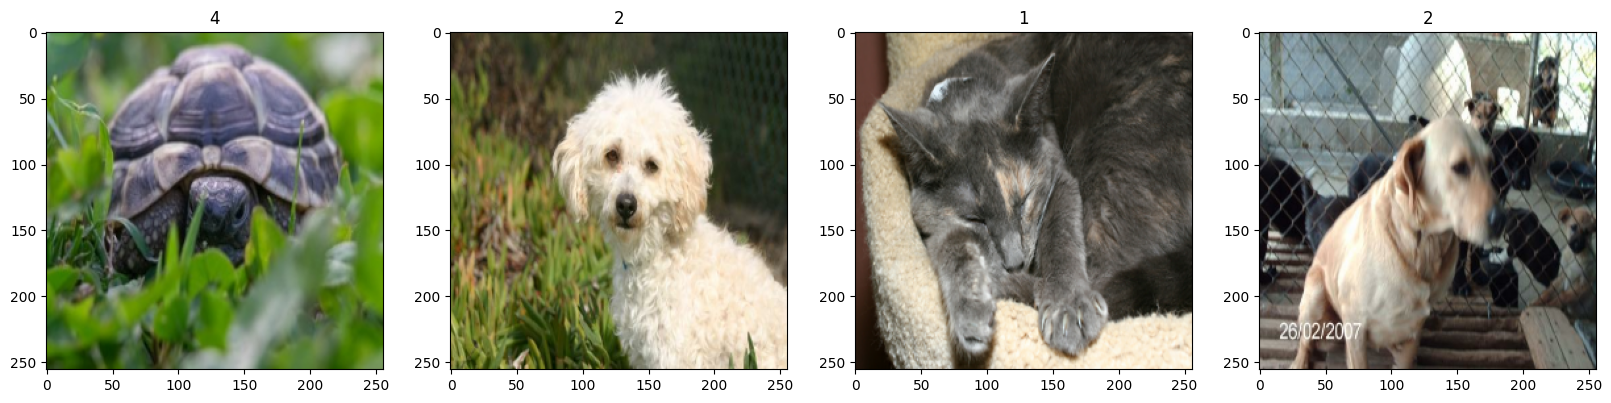

In [151]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

# Preprocesamiento de datos

In [152]:
scaled = batch[0] / 255

In [153]:
scaled.max()

np.float32(1.0)

In [154]:
scaled.min()

np.float32(0.0)

## Escalamiento de datos


In [155]:
data = data.map(lambda x,y: (x/255, y))

In [156]:
scaled_iterator = data.as_numpy_iterator()

In [157]:
batch = scaled_iterator.next()

In [158]:
batch[0].max()

np.float32(1.0)

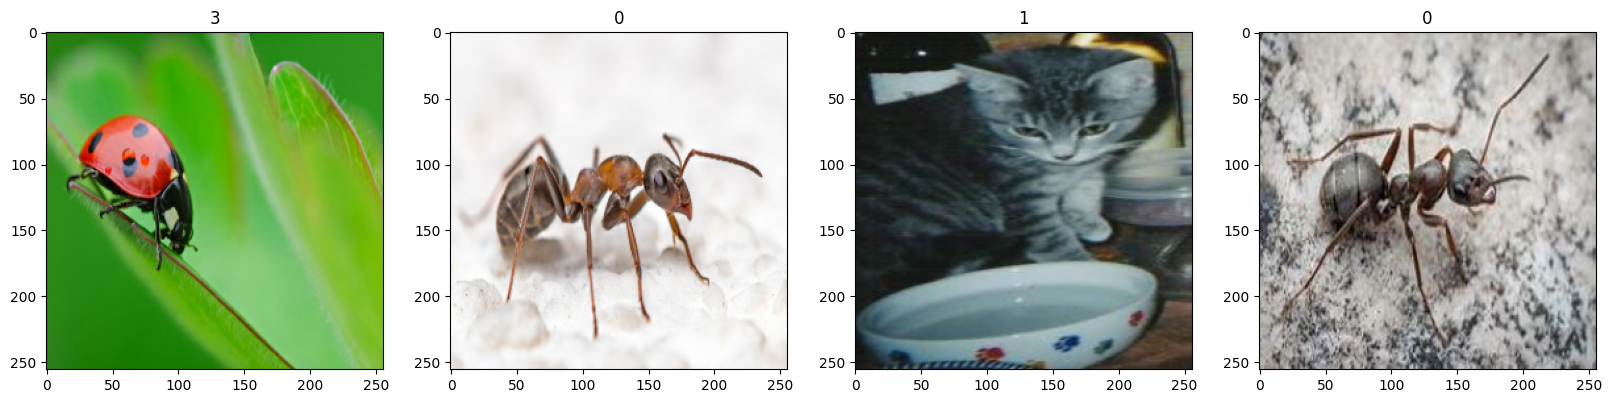

In [159]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(batch[1][idx])

## Split Data

In [160]:
len(data)

101

In [161]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)
test_size = int(len(data)*.1)


In [162]:
test_size

10

In [163]:
train = data.take(train_size)
val = data.skip(val_size)
test = data.skip(test_size)

In [164]:
len(test)

91

# Deep Model

In [165]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dropout, Dense

In [166]:
model = Sequential()

In [167]:
model.add(Conv2D(16, (3,3), activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D())

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dense(5, activation='softmax'))


c:\Users\ang3l\Documents\InteligenciaArtificial\cnn\classifier\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [168]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)


In [169]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 60, 60, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     7,373,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,388,677 (28.19 MB)

 Trainable params: 7,388,677 (28.19 MB)

 Non-trainable params: 0 (0.00 B)

# Train

In [170]:
logdir = 'logs'

In [171]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [172]:
hist = model.fit(train, epochs=20, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 37s 489ms/step - accuracy: 0.4156 - loss: 1.5116 - val_accuracy: 0.6019 - val_loss: 0.9611
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 27s 383ms/step - accuracy: 0.6071 - loss: 0.9092 - val_accuracy: 0.6745 - val_loss: 0.8419
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 27s 379ms/step - accuracy: 0.6808 - loss: 0.7622 - val_accuracy: 0.6734 - val_loss: 0.8119
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 27s 379ms/step - accuracy: 0.7317 - loss: 0.6667 - val_accuracy: 0.7633 - val_loss: 0.6343
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 26s 375ms/step - accuracy: 0.7862 - loss: 0.5302 - val_accuracy: 0.7266 - val_loss: 0.6648
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 26s 372ms/step - accuracy: 0.8500 - loss: 0.3965 - val_accuracy: 0.8320 - val_loss: 0.5160
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 27s 378ms/step - accuracy: 0.9071 - loss: 0.2766 - val_accuracy: 0.8560 - val_loss: 0.4802
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 27s 387ms/step - accuracy: 0.9214 - loss: 0.2348 - val_accu

In [174]:
hist.history

{'accuracy': [0.4156250059604645,
  0.6071428656578064,
  0.6808035969734192,
  0.7316964268684387,
  0.7861607074737549,
  0.8500000238418579,
  0.9071428775787354,
  0.9214285612106323,
  0.9513393044471741,
  0.9691964387893677,
  0.9861606955528259,
  0.9897321462631226,
  0.9816964268684387,
  0.9799107313156128,
  0.9906250238418579,
  0.9937499761581421,
  0.9973214268684387,
  1.0,
  0.9991071224212646,
  0.9991071224212646],
 'loss': [1.511575698852539,
  0.9092435240745544,
  0.7622163891792297,
  0.6667119264602661,
  0.5301749110221863,
  0.3965245187282562,
  0.2766087055206299,
  0.23481516540050507,
  0.14048314094543457,
  0.10595813393592834,
  0.052651748061180115,
  0.04114343598484993,
  0.06989343464374542,
  0.07619348913431168,
  0.039664074778556824,
  0.036090899258852005,
  0.010506421327590942,
  0.003436340019106865,
  0.0032513306941837072,
  0.00663867499679327],
 'val_accuracy': [0.6019304990768433,
  0.6745173931121826,
  0.6733590960502625,
  0.76332044

## Mostrar rendimiento

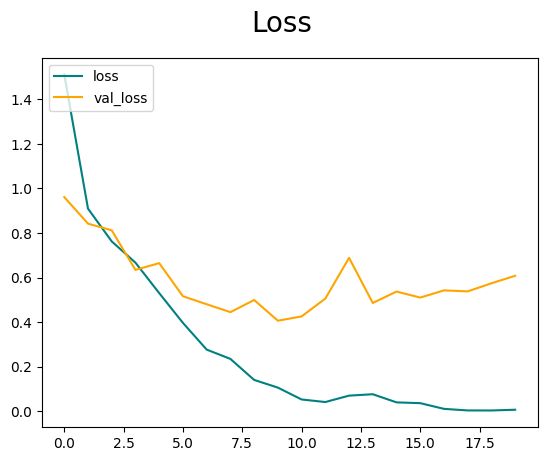

In [176]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

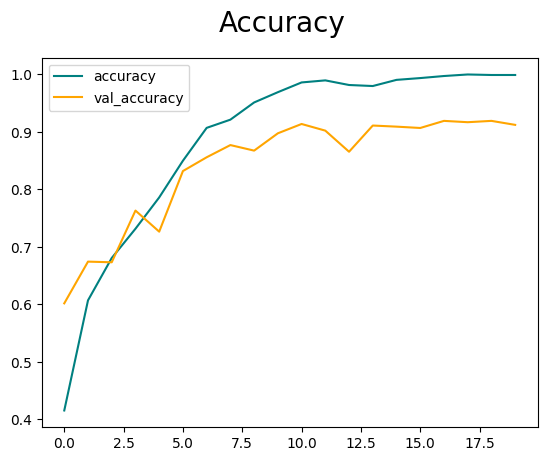

In [177]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

# Evalucion de rendimiento

## Evaluacion

In [180]:
val_loss, val_acc = model.evaluate(val)
print(f"Val loss: {val_loss:.4f}")
print(f"Val accuracy: {val_acc:.4f}")




81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.9124 - loss: 0.6080
Val loss: 0.6080
Val accuracy: 0.9124


In [181]:
import numpy as np

y_pred_probs = model.predict(val)
y_pred = np.argmax(y_pred_probs, axis=1)


81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step


In [182]:
y_pred

array([4, 4, 1, ..., 2, 1, 1], shape=(2590,))

In [183]:
y_true = np.concatenate([y for x, y in val])


In [184]:
y_true

array([3, 0, 4, ..., 2, 3, 1], shape=(2590,), dtype=int32)

In [185]:
print("Pred:", y_pred.shape)
print("True:", y_true.shape)


Pred: (2590,)
True: (2590,)


In [188]:
from tensorflow.keras.metrics import SparseCategoricalAccuracy


acc = SparseCategoricalAccuracy()


In [189]:


for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X, verbose=0)  # softmax probabilities
    acc.update_state(y, yhat)


In [190]:
print("Accuracy:", acc.result().numpy())


Accuracy: 0.92199314


# Test

In [191]:
import cv2

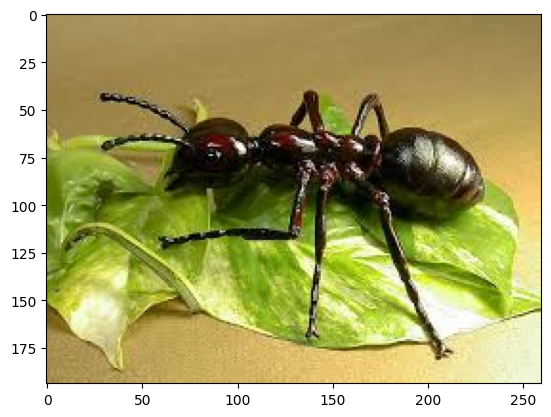

In [240]:
img = cv2.imread('anttest.jpg')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

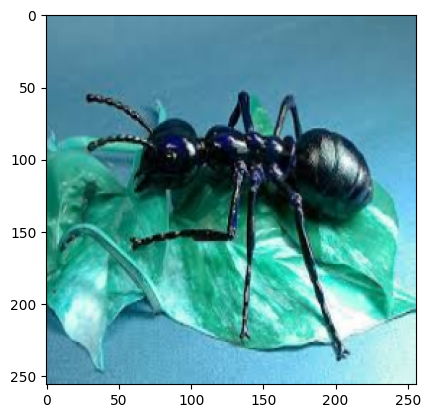

In [241]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [242]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


In [243]:
import numpy as np

predicted_class = np.argmax(yhat)
confidence = np.max(yhat)

print("Clase predicha:", predicted_class)
print("Confianza:", confidence)


Clase predicha: 4
Confianza: 0.56820184


In [245]:
from tensorflow.keras.models import load_model

In [246]:
model.save(os.path.join('models', 'classifierV1.h5'))

In [249]:
new_model = load_model(os.path.join('models', 'classifierV1.h5'))

In [250]:
new_model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step


array([[2.5466782e-06, 6.4656371e-07, 2.3821707e-07, 4.3179464e-01,
        5.6820184e-01]], dtype=float32)